# Análisis de Burnout en Desarrolladores de Software
### Fase 1: Comprensión de los Datos (EDA) &nbsp;|&nbsp; Fase 2: Regresión Lineal

**Dataset:** `developer_burnout_dataset_7000.csv` (7000 registros, 11 variables numéricas + 1 categórica)

**Objetivo de la regresión:** predecir `stress_level` (variable continua, 0–100) a partir de las variables de hábitos y contexto laboral del desarrollador.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("developer_burnout_dataset_7000.csv")
df.shape


(7000, 12)

## 1. Comprensión de los datos

### 1.1 Vista general

In [2]:
df.head()


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,55.96,Medium
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,82.22,High
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54,61.77,Medium
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,54.98,Medium
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36,27.90,Low


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               6860 non-null   float64
 1   experience_years  6860 non-null   float64
 2   daily_work_hours  6860 non-null   float64
 3   sleep_hours       6860 non-null   float64
 4   caffeine_intake   6860 non-null   float64
 5   bugs_per_day      6860 non-null   float64
 6   commits_per_day   6860 non-null   float64
 7   meetings_per_day  6860 non-null   float64
 8   screen_time       6860 non-null   float64
 9   exercise_hours    6860 non-null   float64
 10  stress_level      6860 non-null   float64
 11  burnout_level     6860 non-null   str    
dtypes: float64(11), str(1)
memory usage: 656.4 KB


### 1.2 Clasificación inicial de variables

| Tipo | Variables |
|---|---|
| **Numéricas continuas** | `age`, `experience_years`, `daily_work_hours`, `sleep_hours`, `caffeine_intake`, `bugs_per_day`, `commits_per_day`, `meetings_per_day`, `screen_time`, `exercise_hours`, `stress_level` |
| **Categórica (target de clasificación)** | `burnout_level` (Low / Medium / High) |

Todas las variables numéricas son de tipo `float64`. La única variable categórica (`burnout_level`) es de tipo texto (`object`) con 3 niveles ordinales.


In [4]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)


Numéricas: ['age', 'experience_years', 'daily_work_hours', 'sleep_hours', 'caffeine_intake', 'bugs_per_day', 'commits_per_day', 'meetings_per_day', 'screen_time', 'exercise_hours', 'stress_level']
Categóricas: ['burnout_level']


### 1.3 Calidad de los datos: valores faltantes y duplicados

In [5]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"faltantes": missing, "% faltantes": missing_pct})


,faltantes,% faltantes
age,140,2.0
experience_years,140,2.0
daily_work_hours,140,2.0
sleep_hours,140,2.0
caffeine_intake,140,2.0
bugs_per_day,140,2.0
commits_per_day,140,2.0
meetings_per_day,140,2.0
screen_time,140,2.0
exercise_hours,140,2.0


In [6]:
print("Filas duplicadas:", df.duplicated().sum())


Filas duplicadas: 0


**Hallazgo preliminar:** hay **140 registros (2%)** con valores faltantes, distribuidos de forma idéntica en todas las columnas (probablemente las mismas 140 filas con datos incompletos). No hay filas duplicadas. Para el EDA se conservan (Pandas los ignora en describe/plots); para el modelo de regresión se eliminarán con `dropna()`.


### 1.4 Estadística descriptiva

In [7]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,6860.0,32.129446,7.230254,20.00,26.0000,32.000,38.0000,44.00
experience_years,6860.0,9.581050,5.760972,0.00,5.0000,10.000,15.0000,19.00
daily_work_hours,6860.0,9.000277,2.863944,4.00,6.5600,8.990,11.4225,14.00
sleep_hours,6860.0,6.485638,1.445008,4.00,5.2200,6.460,7.7400,9.00
caffeine_intake,6860.0,3.540671,2.283445,0.00,2.0000,4.000,6.0000,7.00
bugs_per_day,6860.0,9.482653,5.751664,0.00,5.0000,9.000,14.0000,19.00
commits_per_day,6860.0,14.458455,8.669846,0.00,7.0000,14.000,22.0000,29.00
meetings_per_day,6860.0,4.545044,2.856766,0.00,2.0000,5.000,7.0000,9.00
screen_time,6860.0,11.974773,3.091204,5.21,9.4600,12.020,14.4225,18.93
exercise_hours,6860.0,1.007611,0.576708,0.00,0.5100,1.020,1.5100,2.00


In [8]:
df["burnout_level"].value_counts(dropna=False)


burnout_level
Medium    3485
High      1782
Low       1593
NaN        140
Name: count, dtype: int64

**Hallazgo:** la clase `Medium` es la más frecuente (≈50%), seguida de `High` (≈25%) y `Low` (≈23%), sobre 6860 registros válidos. Hay un leve desbalance, relevante si más adelante se hace clasificación, pero no afecta la regresión lineal sobre `stress_level`.


## 2. Análisis exploratorio: distribuciones univariadas

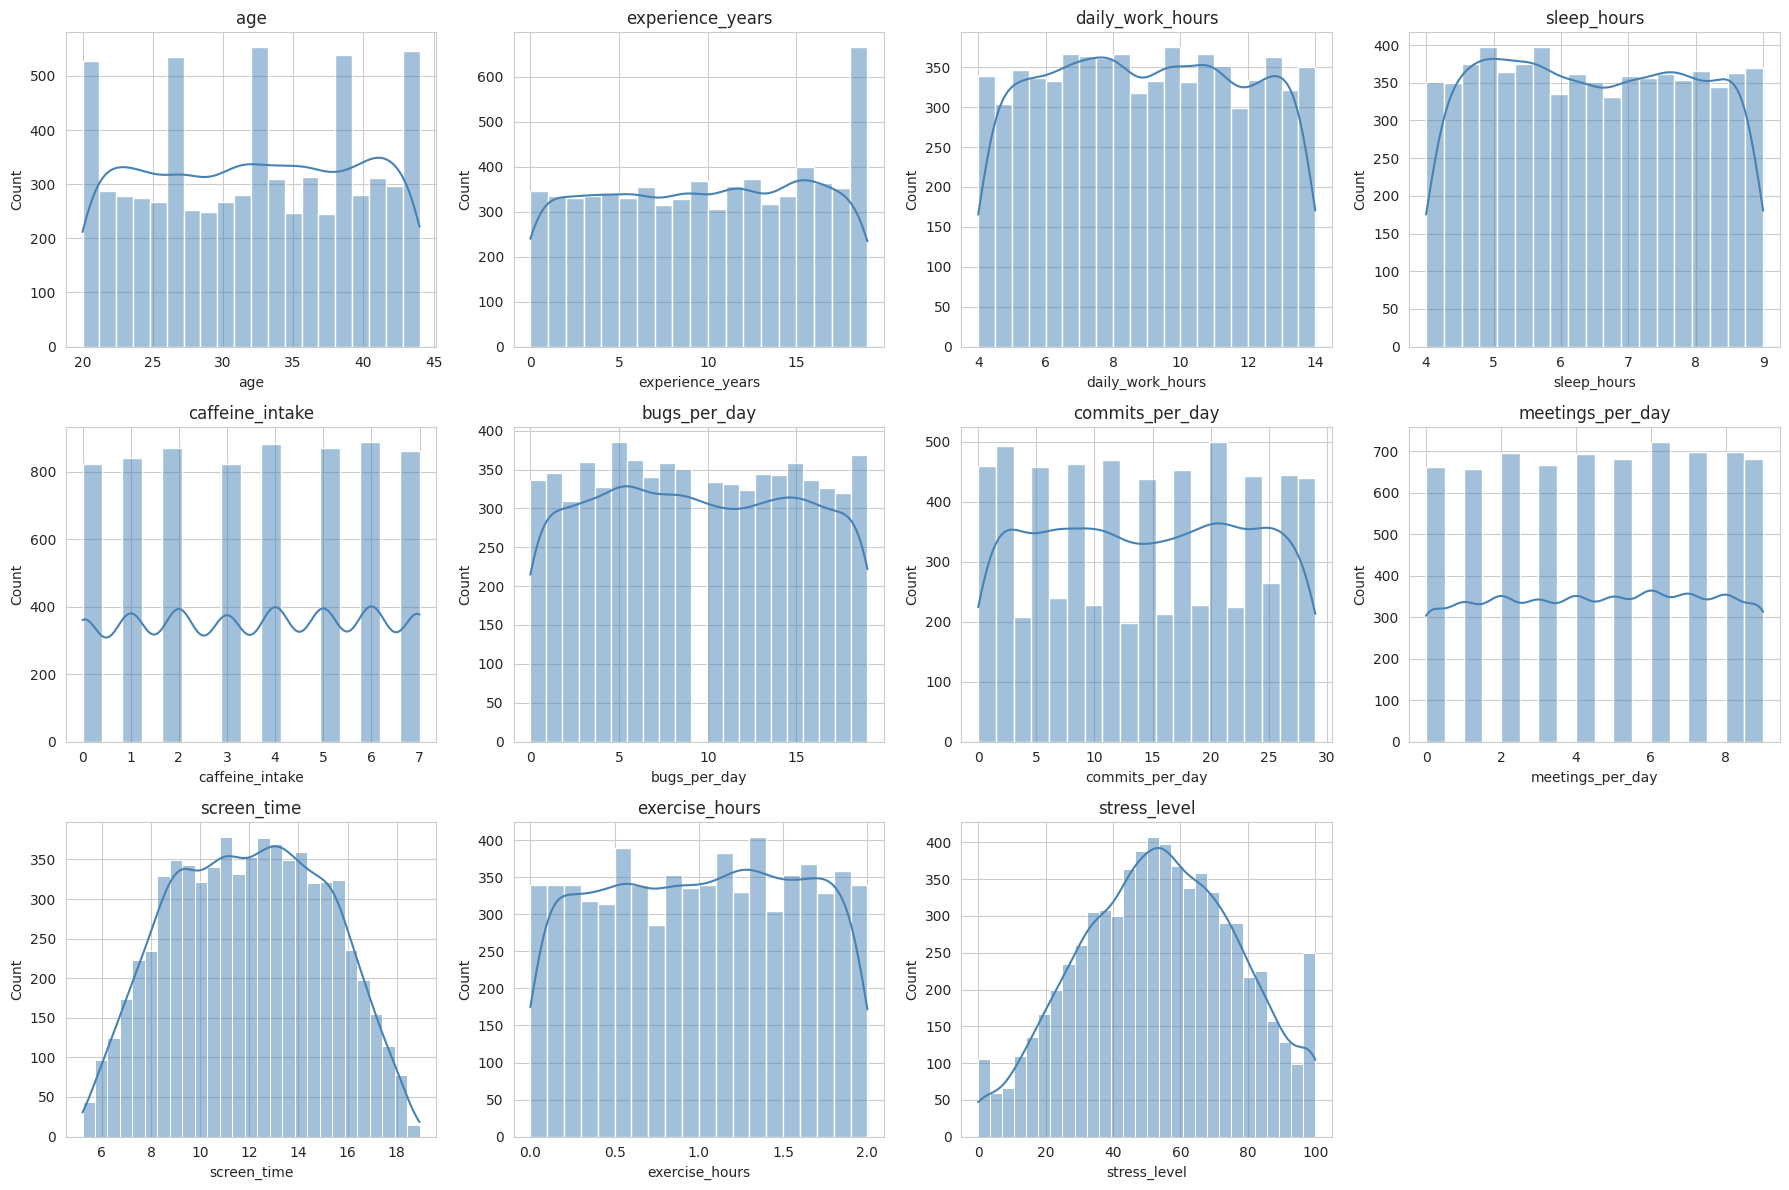

In [9]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(col)
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


/tmp/ipykernel_475/2131353630.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="burnout_level", order=["Low","Medium","High"], palette="viridis")


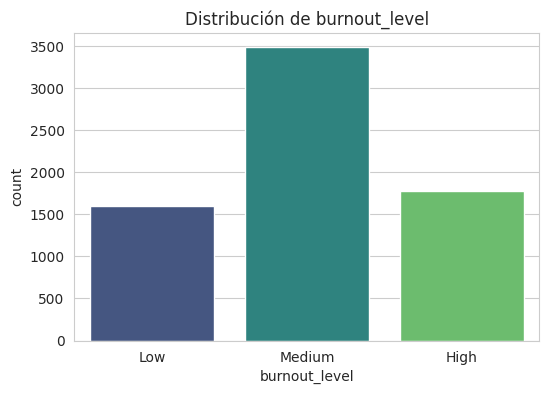

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="burnout_level", order=["Low","Medium","High"], palette="viridis")
plt.title("Distribución de burnout_level")
plt.show()


**Hallazgos preliminares:**
- `age`, `experience_years`, `sleep_hours`, `screen_time` y `exercise_hours` muestran distribuciones aproximadamente uniformes o levemente simétricas, típicas de datos simulados.
- `stress_level` cubre todo el rango 0–100 con una distribución razonablemente simétrica, adecuada como variable objetivo continua para regresión lineal.
- `daily_work_hours` y `caffeine_intake` muestran cierta concentración en valores medios-altos, coherente con el perfil de un desarrollador con carga de trabajo elevada.


## 3. Detección de outliers (boxplots)

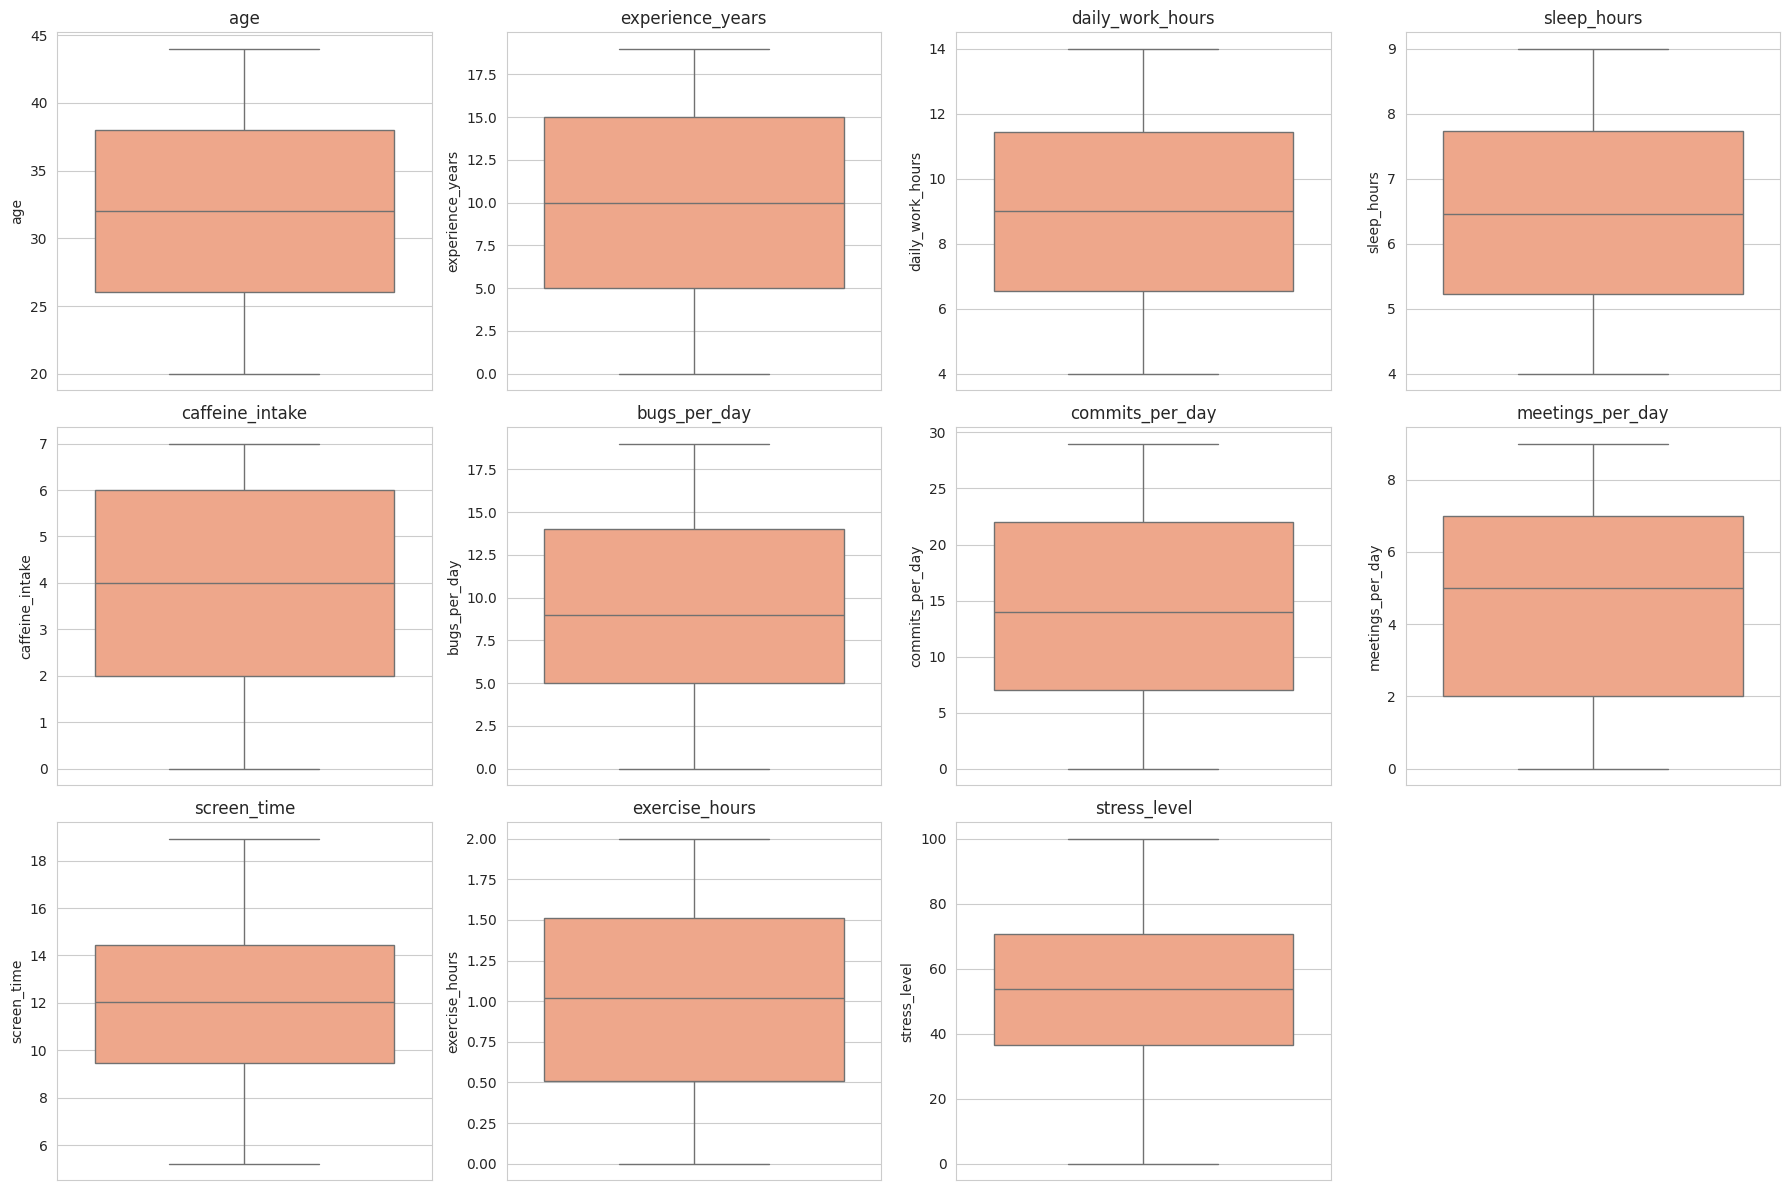

In [11]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="lightsalmon")
    axes[i].set_title(col)
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


No se observan outliers extremos: los valores se mantienen dentro de rangos plausibles para cada variable (p. ej. `sleep_hours` entre 0 y ~10, `stress_level` entre 0 y 100), consistente con un dataset generado/controlado.


## 4. Relaciones bivariadas

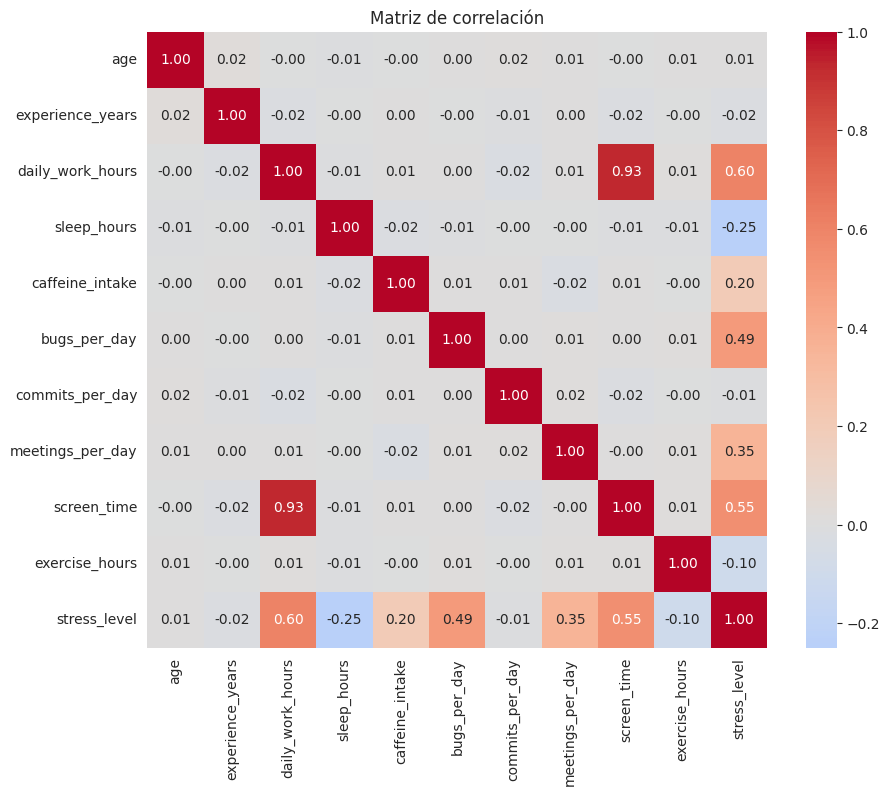

In [12]:
corr = df[num_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()


In [13]:
corr["stress_level"].sort_values(ascending=False)


stress_level        1.000000
daily_work_hours    0.600880
screen_time         0.548701
bugs_per_day        0.492421
meetings_per_day    0.351155
caffeine_intake     0.199618
age                 0.006457
commits_per_day    -0.007626
experience_years   -0.019935
exercise_hours     -0.104551
sleep_hours        -0.249907
Name: stress_level, dtype: float64

**Hallazgo clave para la regresión:** las variables con mayor correlación (en valor absoluto) con `stress_level` son las que aportarán más poder predictivo al modelo lineal. Se observa correlación positiva con variables de carga (`daily_work_hours`, `meetings_per_day`, `bugs_per_day`) y negativa con variables de descanso (`sleep_hours`, `exercise_hours`), en línea con la intuición del dominio.


/tmp/ipykernel_475/2694464383.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="burnout_level", y="stress_level", order=["Low","Medium","High"], palette="viridis")


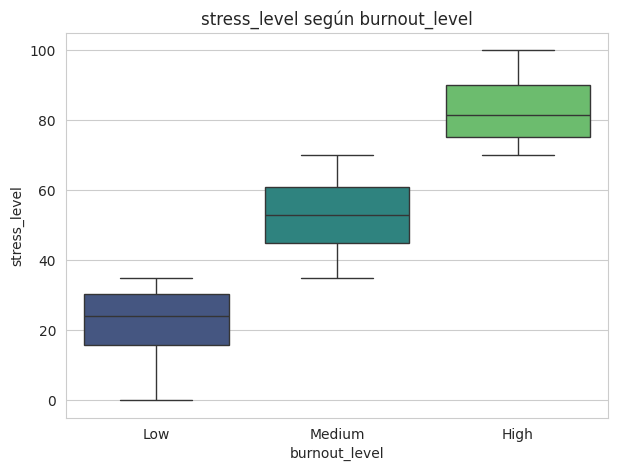

In [14]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="burnout_level", y="stress_level", order=["Low","Medium","High"], palette="viridis")
plt.title("stress_level según burnout_level")
plt.show()


Como es esperable, `stress_level` aumenta de forma monótona entre las categorías Low → Medium → High de `burnout_level`, lo que valida la coherencia interna del dataset.


## 5. Fase 2: Regresión Lineal — Predicción de `stress_level`

### 5.1 Preparación de los datos

Se eliminan los registros con valores faltantes y se separan variables predictoras (X) y variable objetivo (y = `stress_level`). No se incluye `burnout_level` como predictor porque está construida a partir del mismo `stress_level` (fuga de información / *data leakage*).


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm

df_model = df.dropna().copy()

features = ["age","experience_years","daily_work_hours","sleep_hours",
            "caffeine_intake","bugs_per_day","commits_per_day",
            "meetings_per_day","screen_time","exercise_hours"]
target = "stress_level"

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (4392, 10) Test: (1098, 10)


### 5.2 Entrenamiento del modelo (scikit-learn)

In [16]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R2   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")


R2   : 0.8257
MAE  : 7.8855
RMSE : 9.9329


### 5.3 Coeficientes del modelo

In [17]:
coef_df = pd.DataFrame({
    "variable": features,
    "coeficiente": lr.coef_
}).sort_values("coeficiente", key=abs, ascending=False)
coef_df["intercepto"] = lr.intercept_
coef_df


,variable,coeficiente,intercepto
9,exercise_hours,-4.945680,1.440398
2,daily_work_hours,4.877895,1.440398
3,sleep_hours,-3.821137,1.440398
7,meetings_per_day,2.817099,1.440398
4,caffeine_intake,2.006585,1.440398
5,bugs_per_day,1.941941,1.440398
1,experience_years,-0.055971,1.440398
6,commits_per_day,-0.020069,1.440398
0,age,0.018845,1.440398
8,screen_time,-0.005225,1.440398


### 5.4 Resumen estadístico completo (statsmodels)

Incluye p-values e intervalos de confianza para evaluar la significancia estadística de cada predictor.


In [18]:
X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_sm).fit()
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:           stress_level   R-squared:                       0.826
Model:                            OLS   Adj. R-squared:                  0.825
Method:                 Least Squares   F-statistic:                     2078.
Date:                Wed, 26 Aug 2026   Prob (F-statistic):               0.00
Time:                        22:59:06   Log-Likelihood:                -16248.
No. Observations:                4392   AIC:                         3.252e+04
Df Residuals:                    4381   BIC:                         3.259e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                1.4404      1.282  

### 5.5 Diagnóstico del modelo: valores reales vs. predichos y residuos

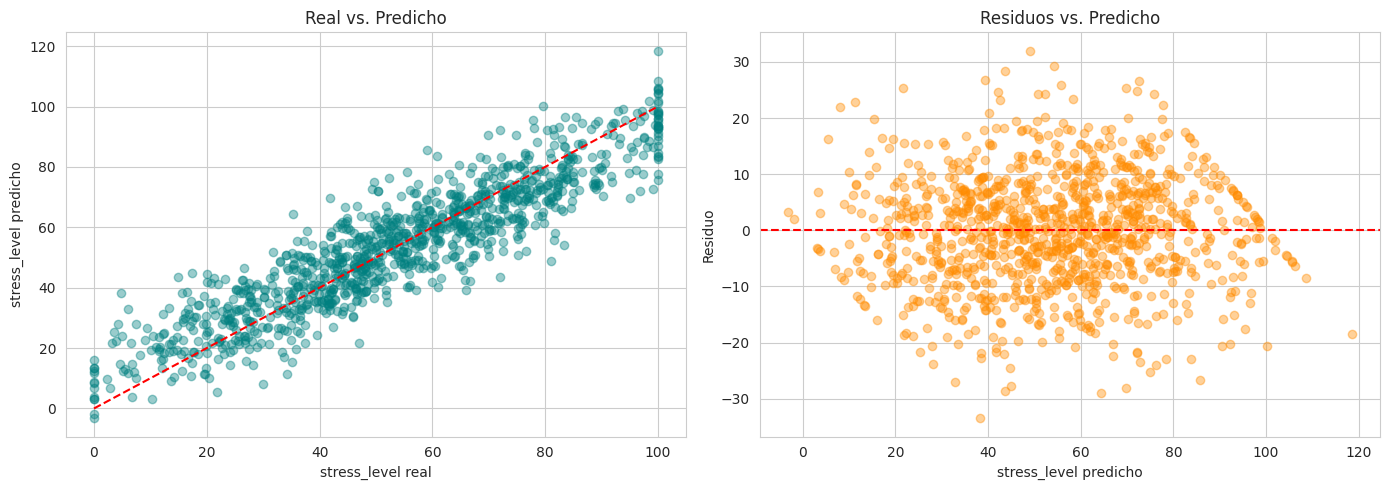

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].scatter(y_test, y_pred, alpha=0.4, color="teal")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel("stress_level real")
axes[0].set_ylabel("stress_level predicho")
axes[0].set_title("Real vs. Predicho")

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, color="darkorange")
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("stress_level predicho")
axes[1].set_ylabel("Residuo")
axes[1].set_title("Residuos vs. Predicho")

plt.tight_layout()
plt.show()


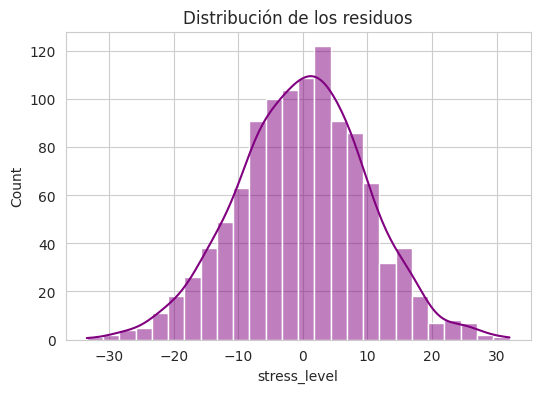

In [20]:
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True, color="purple")
plt.title("Distribución de los residuos")
plt.show()


## 6. Conclusiones preliminares

- El EDA muestra un dataset limpio (sin duplicados, ~2% de faltantes), con variables en rangos coherentes y sin outliers extremos.
- `stress_level` correlaciona de forma esperable con variables de carga laboral (positivo) y de descanso (negativo), y aumenta monótonamente con `burnout_level`, lo que da consistencia interna al dataset.
- El modelo de regresión lineal permite cuantificar cuánto aporta cada hábito/variable laboral al nivel de estrés predicho (ver coeficientes y p-values de la sección 5.3–5.4).
- Los gráficos de diagnóstico (real vs. predicho, residuos) permiten evaluar si la relación lineal es adecuada o si conviene explorar modelos no lineales en una fase posterior.

*(Los valores exactos de R², coeficientes y significancia se completan al ejecutar el notebook con tus datos — ver salidas de las celdas de código arriba.)*


## 7. Fase 3: Árbol de Decisión y Random Forest

Se comparan dos modelos basados en árboles contra la regresión lineal de la sección anterior, usando el **mismo target** (`stress_level`) y el **mismo split** train/test para que la comparación sea justa.

- **Árbol de decisión (Decision Tree Regressor):** modelo simple e interpretable, pero propenso a sobreajustar si no se limita su profundidad.
- **Random Forest Regressor:** promedio de muchos árboles entrenados con submuestras aleatorias (bagging); suele generalizar mejor y ser más robusto que un único árbol.


### 7.1 Entrenamiento de ambos modelos

In [21]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor

# Árbol de decisión (profundidad limitada para evitar overfitting y poder visualizarlo)
tree_model = DecisionTreeRegressor(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

# Random Forest
rf_model = RandomForestRegressor(n_estimators=300, max_depth=None, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Modelos entrenados.")


Modelos entrenados.


### 7.2 Comparación de métricas: Lineal vs. Árbol vs. Random Forest

In [22]:
def metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))
    }

comparison = pd.DataFrame({
    "Regresión Lineal": metrics(y_test, y_pred),
    "Árbol de Decisión": metrics(y_test, y_pred_tree),
    "Random Forest": metrics(y_test, y_pred_rf),
}).T.round(4)

comparison


,R2,MAE,RMSE
Regresión Lineal,0.8257,7.8855,9.9329
Árbol de Decisión,0.5957,12.0627,15.1292
Random Forest,0.7821,8.9727,11.1075


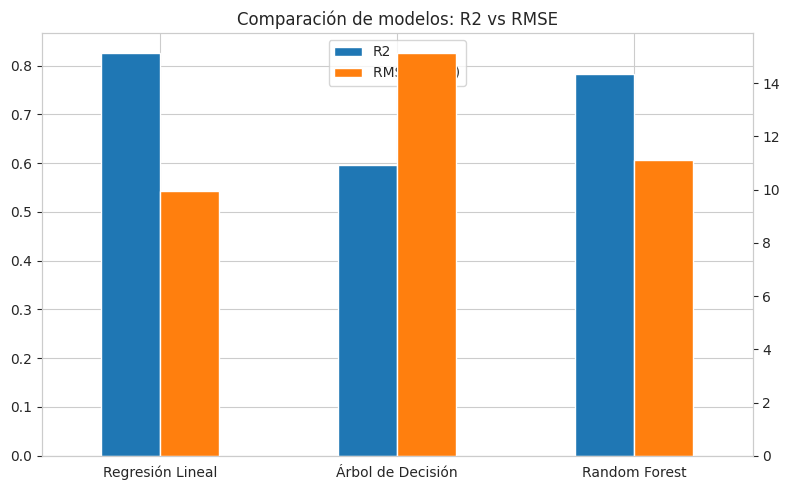

In [23]:
comparison[["R2","RMSE"]].plot(kind="bar", figsize=(8,5), secondary_y="RMSE", rot=0)
plt.title("Comparación de modelos: R2 vs RMSE")
plt.tight_layout()
plt.show()


### 7.3 Importancia de variables (Random Forest)

A diferencia de los coeficientes de la regresión lineal (que asumen relación lineal), la importancia de variables de Random Forest mide cuánto reduce cada variable el error del modelo en promedio, sin asumir linealidad.


In [24]:
importances = pd.DataFrame({
    "variable": features,
    "importancia_rf": rf_model.feature_importances_,
    "importancia_tree": tree_model.feature_importances_
}).sort_values("importancia_rf", ascending=False)

importances


,variable,importancia_rf,importancia_tree
2,daily_work_hours,0.388514,0.530275
5,bugs_per_day,0.245395,0.302515
7,meetings_per_day,0.123104,0.154566
3,sleep_hours,0.083621,0.012644
4,caffeine_intake,0.041753,0.000000
9,exercise_hours,0.036199,0.000000
8,screen_time,0.025871,0.000000
6,commits_per_day,0.019270,0.000000
0,age,0.018229,0.000000
1,experience_years,0.018044,0.000000


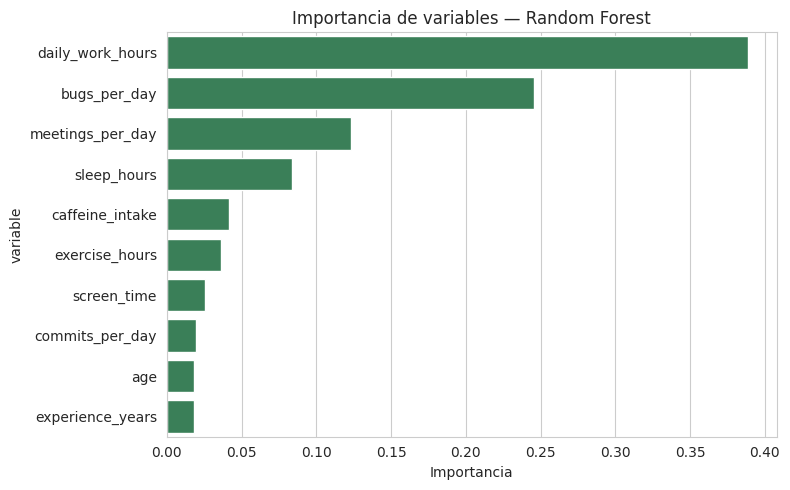

In [25]:
plt.figure(figsize=(8,5))
sns.barplot(data=importances, y="variable", x="importancia_rf", color="seagreen")
plt.title("Importancia de variables — Random Forest")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()


### 7.4 Visualización del árbol de decisión (profundidad 4)

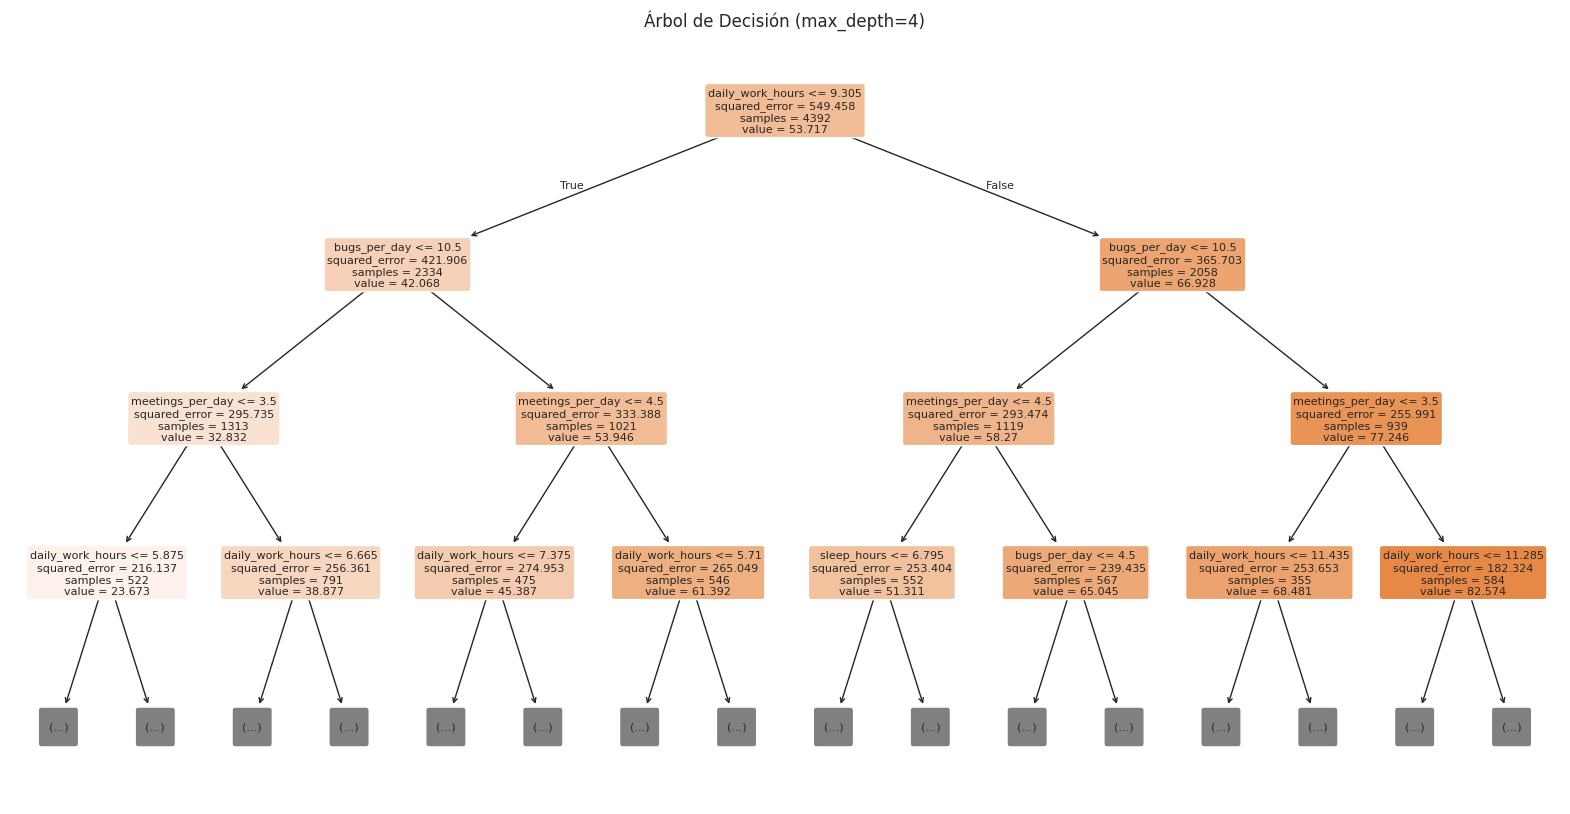

In [26]:
plt.figure(figsize=(20,10))
plot_tree(tree_model, feature_names=features, filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title("Árbol de Decisión (max_depth=4)")
plt.show()


### 7.5 Real vs. Predicho — Random Forest

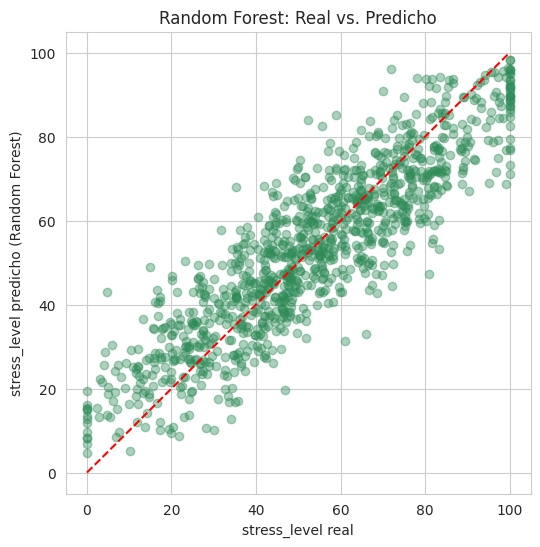

In [27]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.4, color="seagreen")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("stress_level real")
plt.ylabel("stress_level predicho (Random Forest)")
plt.title("Random Forest: Real vs. Predicho")
plt.show()


## 8. Conclusiones — comparación de modelos

- Los tres modelos predicen `stress_level` sobre el mismo conjunto de test, lo que permite comparar directamente sus métricas (R², MAE, RMSE) en la tabla de la sección 7.2.
- El **Random Forest** suele capturar mejor interacciones y no linealidades entre variables (p. ej. combinaciones de `daily_work_hours` + `sleep_hours`) que la regresión lineal no puede representar, a costa de perder interpretabilidad directa (coeficientes).
- El **árbol de decisión individual**, aun limitado a profundidad 4, sirve como herramienta explicativa: se puede leer directamente qué combinaciones de variables llevan a estrés alto o bajo (ver sección 7.4).
- La importancia de variables del Random Forest (7.3) permite contrastar qué variables considera más relevantes un modelo no lineal frente a los coeficientes/p-values de la regresión lineal (sección 5.3–5.4): si coinciden las variables top, refuerza la confianza en cuáles son los verdaderos factores de riesgo de estrés.
